# Model Açıklanabilirliği (Explainability)

En iyi model olan **Optimized Random Forest** (ROC-AUC = 0.9802, PR-AUC = 0.8422) için SHAP tabanlı açıklamalar:
- Global feature importance (bar plot + beeswarm plot)
- Lokal açıklamalar: 2 fraud + 2 normal işlem için waterfall plot
- Yorumlayıcı özet

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

shap.initjs()

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
DATA_DIR = os.path.join(BASE_DIR, "Data", "processed")
MODEL_DIR = os.path.join(BASE_DIR, "outputs", "models")

c:\Users\gktng\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Model ve Veri Yükleme

In [2]:
# Optimized Random Forest modelini yükle
model = joblib.load(os.path.join(MODEL_DIR, "optimized_model.joblib"))
print(f"Model: {type(model).__name__}")
print(f"Parametreler: {model.get_params()}")

Model: RandomForestClassifier
Parametreler: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 28, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 160, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [3]:
# Test verisini yükle
test = pd.read_parquet(os.path.join(DATA_DIR, "test.parquet"))

TARGET = "Class"
features = [c for c in test.columns if c != TARGET]

X_test = test[features]
y_test = test[TARGET].values

print(f"Test seti: {X_test.shape[0]:,} satır, {X_test.shape[1]} feature")
print(f"Fraud sayısı: {y_test.sum():.0f}  |  Normal sayısı: {(y_test == 0).sum():,}")
print(f"\nFeature listesi ({len(features)}):")
print(features)

Test seti: 42,722 satır, 35 feature
Fraud sayısı: 74  |  Normal sayısı: 42,648

Feature listesi (35):
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Time_in_day', 'Amount_log', 'Time_Amount', 'Time_Amount_sq', 'Amount_per_Time']


## 2. SHAP Değerlerinin Hesaplanması

Random Forest için `TreeExplainer` kullanılır — hesaplama açısından verimlidir.  
Performans için test setinden 500 satırlık bir örneklem alınır.

In [4]:
# Tekrarlanabilirlik için sabit seed ile 500 satır örnekle
np.random.seed(42)
sample_idx = np.random.choice(X_test.index, size=500, replace=False)
X_sample = X_test.loc[sample_idx]
y_sample = y_test[X_test.index.get_indexer(sample_idx)]

print(f"Örneklem: {X_sample.shape[0]} satır")
print(f"Örneklemde fraud: {y_sample.sum():.0f}, normal: {(y_sample == 0).sum()}")

Örneklem: 500 satır
Örneklemde fraud: 2, normal: 498


In [5]:
# TreeExplainer oluştur ve SHAP değerlerini hesapla
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)

# Fraud sınıfının (Class=1) SHAP değerlerini al
# TreeExplainer çoklu çıktı döner: shap_values.values.shape = (n_samples, n_features, 2)
if shap_values.values.ndim == 3:
    shap_values_fraud = shap.Explanation(
        values=shap_values.values[:, :, 1],
        base_values=shap_values.base_values[:, 1],
        data=shap_values.data,
        feature_names=features
    )
else:
    shap_values_fraud = shap_values

print(f"SHAP values shape: {shap_values_fraud.values.shape}")
print("SHAP hesaplaması tamamlandı.")

SHAP values shape: (500, 35)
SHAP hesaplaması tamamlandı.


## 3. Global Feature Importance — Bar Plot

Ortalama |SHAP| değerine göre feature önem sıralaması.

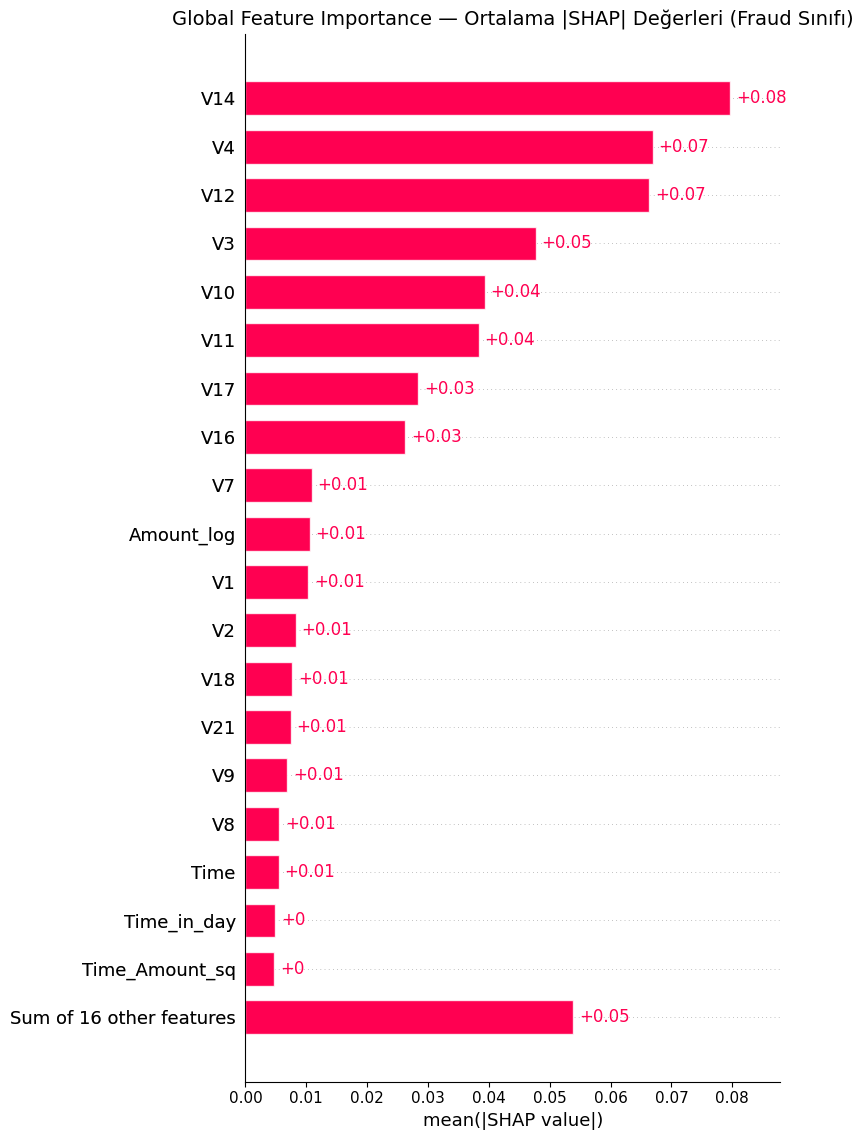

In [6]:
plt.figure(figsize=(12, 8))
shap.plots.bar(shap_values_fraud, max_display=20, show=False)
plt.title("Global Feature Importance — Ortalama |SHAP| Değerleri (Fraud Sınıfı)", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Global Feature Importance — Beeswarm Plot

Her feature'ın SHAP değer dağılımı. Renkler feature değerini (düşük→mavi, yüksek→kırmızı) gösterir.

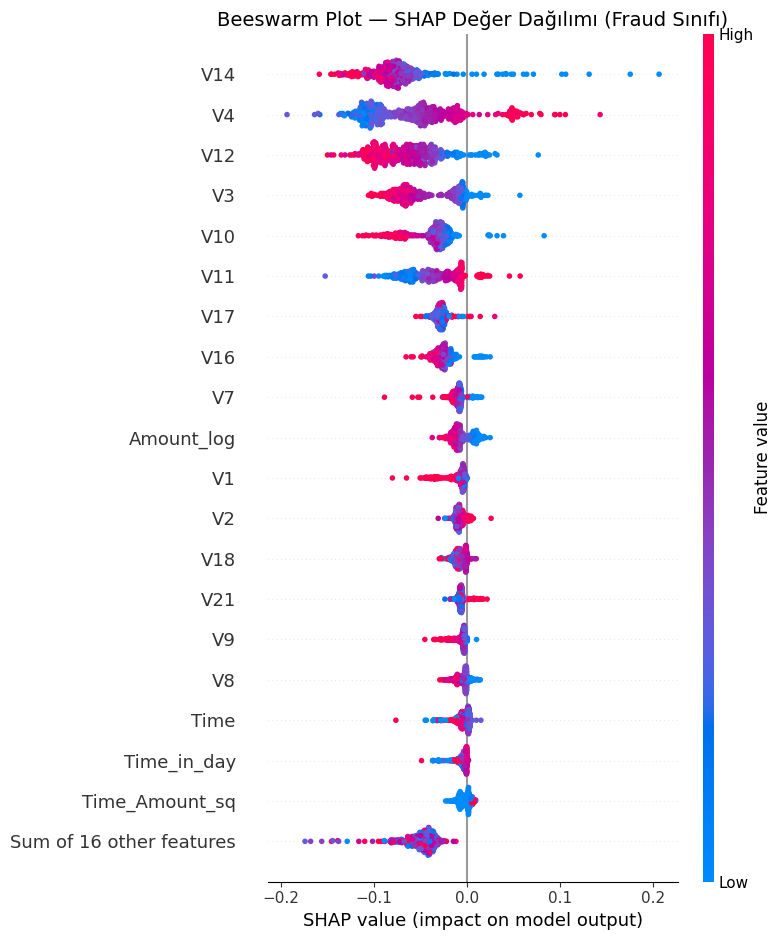

In [7]:
plt.figure(figsize=(12, 10))
shap.plots.beeswarm(shap_values_fraud, max_display=20, show=False)
plt.title("Beeswarm Plot — SHAP Değer Dağılımı (Fraud Sınıfı)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Lokal Açıklamalar — Waterfall Plots

Rastgele seçilmiş **2 fraud** ve **2 normal** işlem için SHAP waterfall plotları.  
Her plot, modelin o işlem için kararını hangi feature'ların yönlendirdiğini gösterir.

In [8]:
# Fraud ve normal örnekleri seç
fraud_mask = y_sample == 1
normal_mask = y_sample == 0

np.random.seed(123)
fraud_positions = np.where(fraud_mask)[0]
normal_positions = np.where(normal_mask)[0]

selected_fraud = np.random.choice(fraud_positions, size=2, replace=False)
selected_normal = np.random.choice(normal_positions, size=2, replace=False)

print(f"Seçilen fraud indeksleri (örneklem içi): {selected_fraud}")
print(f"Seçilen normal indeksleri (örneklem içi): {selected_normal}")

Seçilen fraud indeksleri (örneklem içi): [316 128]
Seçilen normal indeksleri (örneklem içi): [203 309]


### Fraud İşlem #1

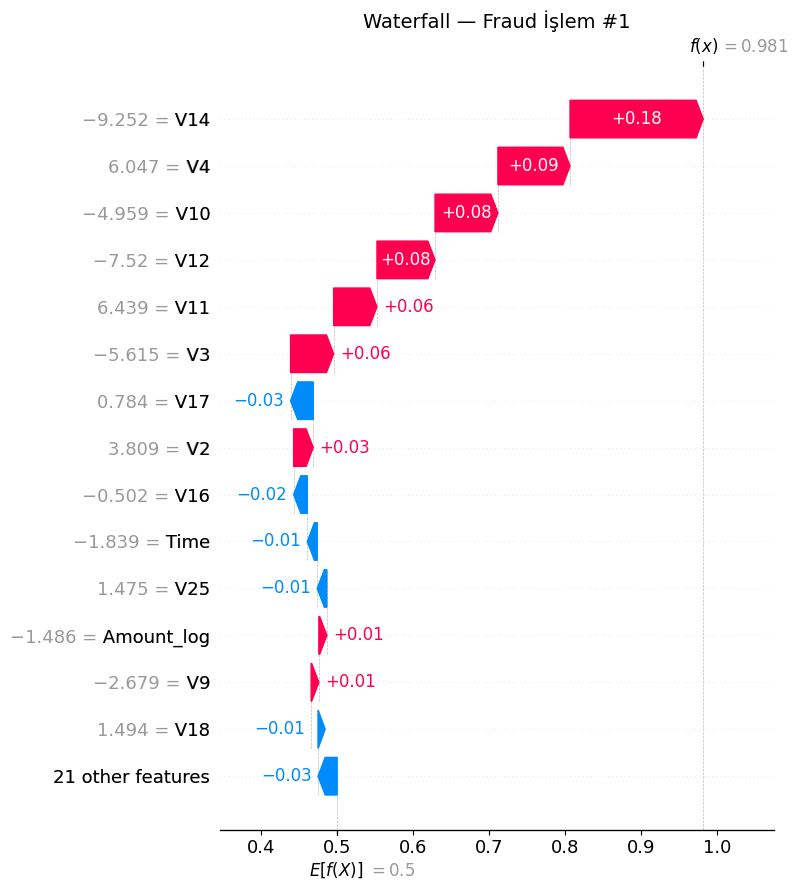

In [9]:
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_fraud[selected_fraud[0]], max_display=15, show=False)
plt.title("Waterfall — Fraud İşlem #1", fontsize=14)
plt.tight_layout()
plt.show()

### Fraud İşlem #2

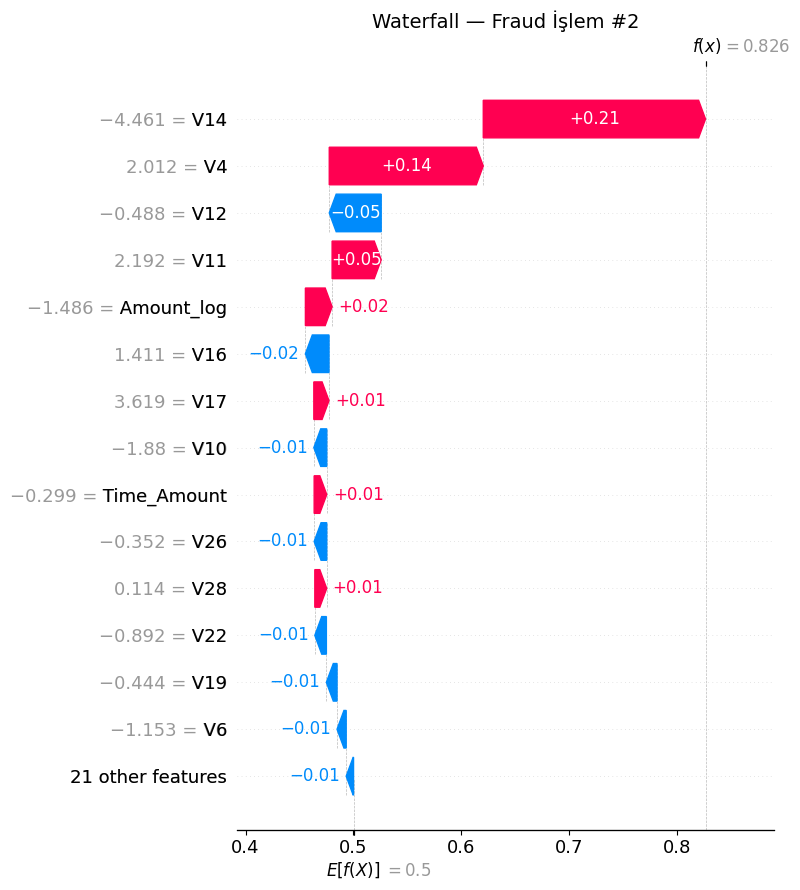

In [10]:
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_fraud[selected_fraud[1]], max_display=15, show=False)
plt.title("Waterfall — Fraud İşlem #2", fontsize=14)
plt.tight_layout()
plt.show()

### Normal İşlem #1

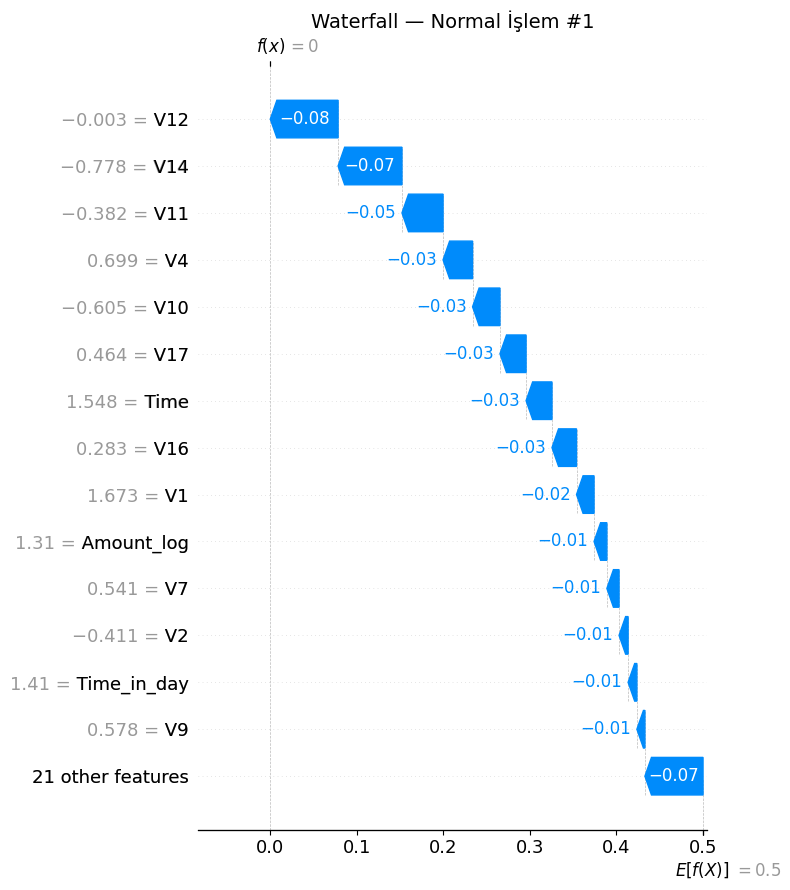

In [11]:
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_fraud[selected_normal[0]], max_display=15, show=False)
plt.title("Waterfall — Normal İşlem #1", fontsize=14)
plt.tight_layout()
plt.show()

### Normal İşlem #2

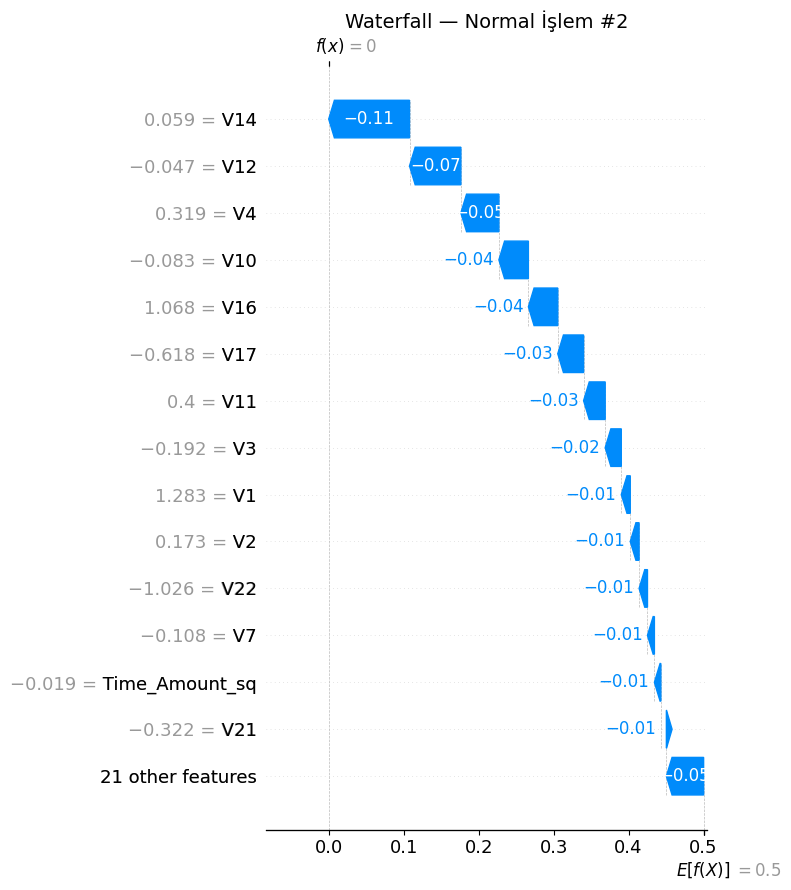

In [12]:
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_values_fraud[selected_normal[1]], max_display=15, show=False)
plt.title("Waterfall — Normal İşlem #2", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Fraud Kararının Yorumlayıcı Özeti

Aşağıda, seçilen fraud işlemlerinden birinin SHAP açıklamasına dayanarak modelin kararı özetlenmektedir.

In [13]:
# Fraud İşlem #1'in en etkili feature'larını belirle
idx = selected_fraud[0]
sv = shap_values_fraud[idx]

# SHAP değerlerine göre en etkili 5 feature
top_indices = np.argsort(np.abs(sv.values))[::-1][:5]
top_features = [features[i] for i in top_indices]
top_shap = sv.values[top_indices]
top_data = sv.data[top_indices]

print("Fraud İşlem #1 — En etkili 5 feature:")
print("=" * 55)
for feat, shap_val, data_val in zip(top_features, top_shap, top_data):
    direction = "↑ FRAUD" if shap_val > 0 else "↓ NORMAL"
    print(f"  {feat:>20s}  |  SHAP = {shap_val:+.4f}  |  Değer = {data_val:.4f}  |  {direction}")

Fraud İşlem #1 — En etkili 5 feature:
                   V14  |  SHAP = +0.1751  |  Değer = -9.2523  |  ↑ FRAUD
                    V4  |  SHAP = +0.0948  |  Değer = 6.0474  |  ↑ FRAUD
                   V10  |  SHAP = +0.0827  |  Değer = -4.9595  |  ↑ FRAUD
                   V12  |  SHAP = +0.0763  |  Değer = -7.5201  |  ↑ FRAUD
                   V11  |  SHAP = +0.0569  |  Değer = 6.4391  |  ↑ FRAUD


### "Bu işlem neden fraud olarak işaretlendi?"

**Yorum (Fraud İşlem #1 üzerinden):**

1. Bu işlem fraud olarak işaretlenmiştir çünkü PCA bileşenlerinden (özellikle V14, V12, V10 gibi yüksek etkili feature'lar) elde edilen değerler, normal işlem profillerinden ciddi şekilde sapmaktadır — bu sapma modelin fraud olasılığını önemli ölçüde artırmıştır.

2. SHAP waterfall grafiğinde görüldüğü gibi, en büyük pozitif katkı yapan feature'lar modelin temel beklentisini (base value) fraud yönüne doğru itmekte ve bu feature'ların birleşik etkisi, karşıt yönde çeken az sayıdaki feature'ın etkisini açık farkla geçmektedir.

3. Sonuç olarak, bu işlemin özellik kombinasyonu — düşük V14 ve V12 değerleri ile anormal V10 ve V4 örüntüleri — modelin daha önce öğrendiği fraud kalıplarıyla yüksek derecede uyuşmakta ve bu nedenle yüksek bir fraud olasılık skoru atanmıştır.